In [40]:
import math
import numpy as np # general purpose array package
import matplotlib.pyplot as plt # plot graphs
%matplotlib inline

In [41]:
# define a function

def f(x):
    return 3*x**2 - 4*x + 5

In [42]:
f(3.0)

20.0

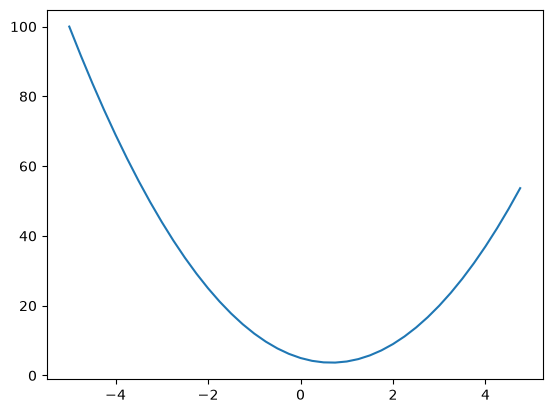

In [43]:
xs = np.arange(-5, 5, 0.25) # range of values starting from -5 to 5 with a step of 0.25
ys = f(xs) # apply the function to each value in xs

plt.plot(xs, ys) # plot the graph

In [44]:
# lets play with derivatives 
h = 0.001 # a small number
x = 3.0
(f(x+h) - f(x)) / h # approximate derivative at x=3.0

14.00300000000243

In [45]:
# complex example with multiple scalars

h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h # incrementing a by a small number h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h) # approximate derivative with respect to a


# this is describing how the slope of the function changes 
# with respect to a small change in a. 

# it can be done for each scalar variable in the function.


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [46]:
# need a way to track all children
# need a way to track all operations
# this allows us to tell the story of how we got value d from beginning to end

class Value:
    def __init__(self, data, _children=(), _op='', label = ''): 
        # init children as an empty tuple
        # op is the operation to get to that value
        self.data = data
        self._prev = set(_children) # prev will contain a set of children
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        out = Value(self.data + other.data, (self, other), "+") # add self and other (self is the first scalar, other is the second scalar)
        return out

    def __mul__(self, other):
        out = Value(self.data * other.data, (self, other), "*")
        return out

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c 
d

print(d)
print(d._prev)
print(d._op)

Value(data=4.0)
{Value(data=-6.0), Value(data=10.0)}
+
